### Where is Waldo

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from helpers import plot_sample_images


import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array, save_img
tf.random.set_seed(42)
np.random.seed(42)

# Report available accelerators
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU acceleration: {len(gpus)} device(s)")
    for gpu in gpus:
        print(f"  {gpu.name}")
else:
    print("No GPU detected — using CPU")

from tensorflow import keras
from keras import Sequential
from keras.layers import (
    Dense, Flatten, Dropout, Conv2D, MaxPooling2D, LSTM, Input
)
from keras.callbacks import EarlyStopping, ModelCheckpoint

# Define image size and batch size
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

#resize all images to 128x128
train_ds = tf.keras.utils.image_dataset_from_directory(
    "data/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)

#rescale pixel values to [0, 1]
from keras.layers import Rescaling

rescale = Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

#confirm rescaling worked
for images, labels in train_ds.take(1):
    print("Pixel value range:", (tf.reduce_min(images).numpy(), tf.reduce_max(images).numpy()))

#start making cnn here no need to further split data


No GPU detected — using CPU
Found 5449 files belonging to 2 classes.
Image batch shape: (32, 128, 128, 3)
Pixel value range: (0.0, 1.0)


In [23]:
#Define Model CNN
waldo_cnn = Sequential([
    Input(shape=(128, 128, 3)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation = 'relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid') 
]) 

#Compile the model
waldo_cnn.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

#Fit the model
history = waldo_cnn.fit(train_ds,
                        epochs=20)




Epoch 1/20
171/171 [==============================] - 48s 273ms/step - loss: 0.4219 - accuracy: 0.9774
Epoch 2/20
171/171 [==============================] - 46s 271ms/step - loss: 0.1093 - accuracy: 0.9824
Epoch 3/20
171/171 [==============================] - 54s 313ms/step - loss: 0.1049 - accuracy: 0.9824
Epoch 4/20
171/171 [==============================] - 56s 324ms/step - loss: 0.1261 - accuracy: 0.9824
Epoch 5/20
171/171 [==============================] - 56s 324ms/step - loss: 0.1007 - accuracy: 0.9826
Epoch 6/20
171/171 [==============================] - 58s 340ms/step - loss: 0.0912 - accuracy: 0.9827
Epoch 7/20
171/171 [==============================] - 57s 335ms/step - loss: 0.0755 - accuracy: 0.9826
Epoch 8/20
171/171 [==============================] - 57s 334ms/step - loss: 0.0764 - accuracy: 0.9831
Epoch 9/20
171/171 [==============================] - 57s 334ms/step - loss: 0.0602 - accuracy: 0.9840
Epoch 10/20
171/171 [==============================] - 55s 322ms/step - l

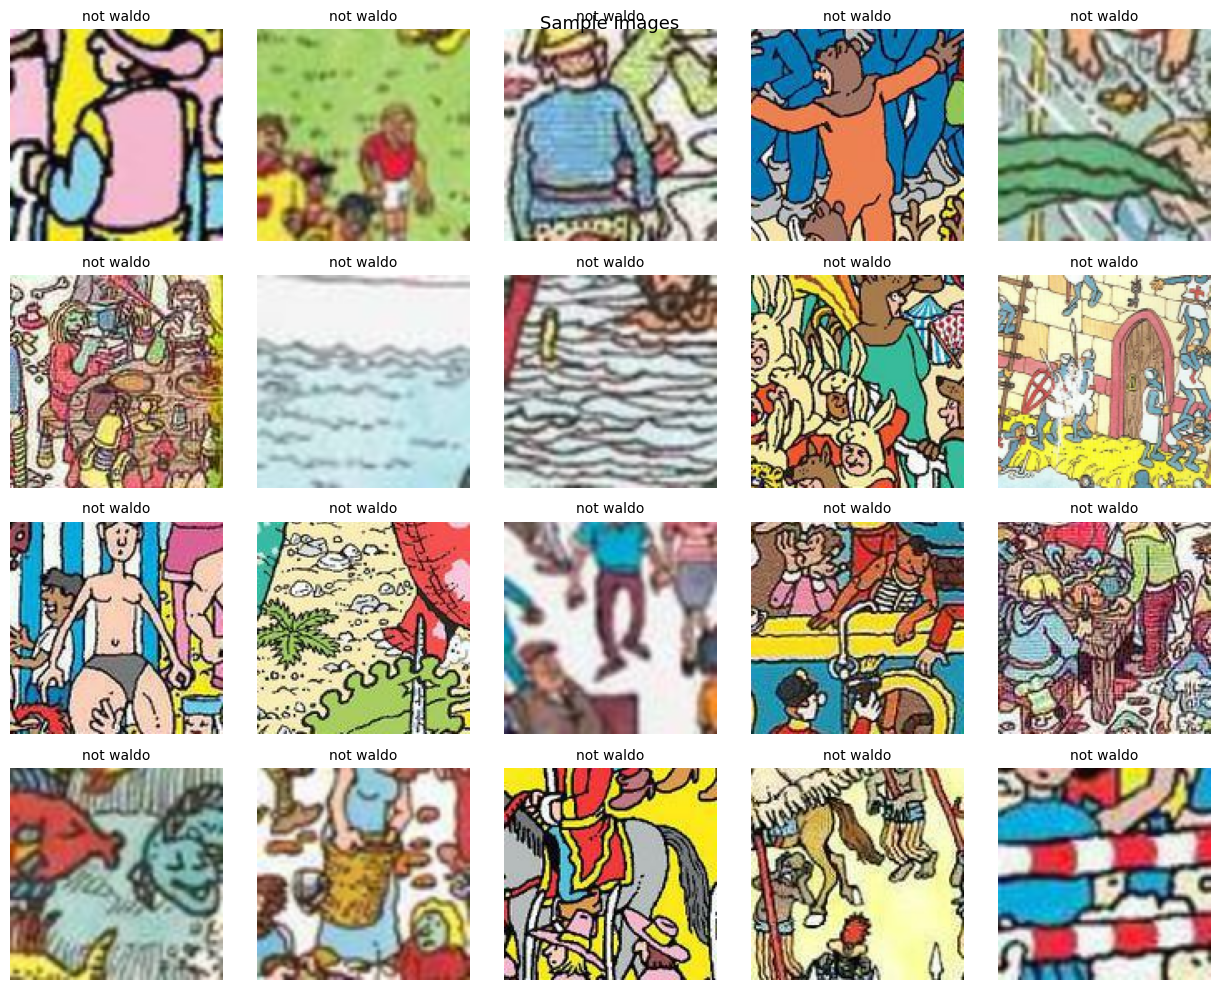

In [19]:
# Test plot_sample_images on the train set
imgs, lbls = next(iter(train_ds))
plot_sample_images(
    imgs.numpy(),
    tf.keras.utils.to_categorical(lbls, 2),
    class_names={0: "not waldo", 1: "waldo"},
    n=20, cols=5
)
